# **Superdense Coding**
Superdense coding is a protocol that allows for the transmission of two classical bits using one qubit of quantum communication.
Superdense coding allows encoding two classical bits into a single qubit, under the condition that sender and receiver initially share a pre-entangled pair (e-bit).

This means that it encodes two classical bits into a single qubit by using an entangled bit (e-bit). In some sense, it achieves a complementary aim to teleportation.

**Superdense coding and Importance of Holevo's theorem:**

Sending a qubit is much more difficult than sending classical bits. For classical communication of two bits without sharing an e-bit, a single qubit cannot communicate more than one classical bit of information. But according to *Holevo's theorem*, without shared entanglement, a single transmitted qubit cannot communicate more than one classical bit of information.

Superdense coding therefore demonstrates that:
> "shared entanglement can effectively double the classical information capacity of a transmitted qubit"

Although transmitting qubits may be technologically more challenging than transmitting classical bits, superdense coding remains important because it provides a clear and clean demonstration of how "entanglement can enhance quantum communication".

### **1. Installing Qiskit packages**
This section installs relevant Qiskit packages to proceed with the project.



In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

#### **1.1 Checking versions:**
Now I will check the versions of installed Qiskit packages to ensure that the required versions are being used for this project.

Usually the following versions are required to implement the superdense coding protocol:
* `qiskit`v2.1.0 or newer
* `qiskit-aer`v0.17.0 or newer

In [ ]:
from qiskit import __version__
print(__version__)

from qiskit_aer import __version__
print(__version__)

2.5.2
0.17.2


#### **1.2 Importing Necessary Libraries**
This section imports necessary classes and functions from Qiskit modules to implement the superdense coding protocol.


In [ ]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import pylatexenc

### **2. Scenario and Protocol Setup**
Consider a sender "Alice" who holds qubit 'A' and a receiver "Bob" who holds qubit 'B', and they share an e-bit of entanglement.
Alice wishes to send two classical bits 'c' and 'd', which will be accomplished using one qubit.

**Circuit operation :**

Here is what Alice does:
* If d = 1, Alice performs a Z gate on her qubit 'A'. If d = 0, she does nothing.
* If c = 1, Alice performs an X gate on her qubit 'A'. If c = 0, she does nothing.

After Bob receives qubit 'A':
* He first performs a C-NOT gate (using A as the control qubit and B, Bob's qubit, as the target qubit).
* Then he performs a Hadamard gate on 'A'.
* He then measures qubits 'A' and 'B' to obtain two classical bits "d" and "c" respectively, with standard basis measurements in both cases.

### **3. Analysis of Superdense coding Protocol**
Alice and Bob initially share the $|\phi ^+\rangle$ state. Depending on the classical bits "c" and "d", Alice either leaves this state or shifts it to one of the other Bell states by applying I, X, Z, or XZ to her qubit 'A'.

$$\begin{aligned}(I \otimes I)|\phi^+\rangle &=|\phi^+\rangle\\(Z \otimes I)|\phi^+\rangle &= |\phi^-\rangle\\(X \otimes I)|\phi^+\rangle &= |\psi^+\rangle\\(XZ \otimes I)|\phi^+\rangle &= |\psi^-\rangle\end{aligned}$$

After Bob's operations (CNOT then Hadamard on Alice's qubit), the four Bell states transform into the following computational basis states:
$$\begin{aligned}|\phi^+\rangle &\rightarrow |00\rangle\\|\phi^-\rangle &\rightarrow |01\rangle\\|\psi^+\rangle &\rightarrow |10\rangle\\|\psi^-\rangle &\rightarrow |11\rangle\end{aligned}$$
So when Bob performs his measurements, he is able to determine which Bell state Alice chose.

### **4. Verification of Protocol**
To verify that the protocol works correctly, we check the following cases:
* If cd = 00, then the state of (B,A) when Bob receives A is $|\phi ^ +\rangle$. He transforms this state into $|00\rangle$ and obtains cd = 00.
* If cd = 01, then the state of (B,A) when Bob receives A is $|\phi ^ -\rangle$. He transforms this state into $|01\rangle$ and obtains cd = 01.
* If cd = 10 , then the state of (B,A) when Bob receives A is $|\psi ^ +\rangle$. He transforms this state into $|10\rangle$ and obtains cd = 10.
* If cd = 11, then the state of (B,A) when Bob receives A is $|\psi ^ -\rangle$. He transforms this state into $-|11\rangle$ and obtains cd = 11.

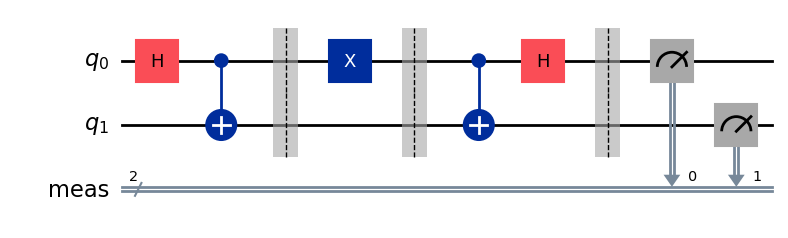

In [ ]:
c = '1'
d = '0'
protocol = QuantumCircuit(2)

# Preparing ebit that will be used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# ALice's operation
if d == '1':
  protocol.z(0)

if c == '1':
  protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)

protocol.measure_all()
display(protocol.draw(output = 'mpl'))


Now I'm going to run Aer simulator.

Measured 10 and with frequency 4096


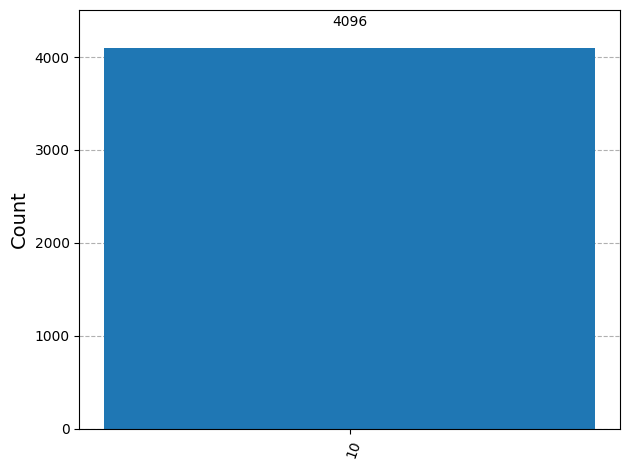

In [ ]:
simulator = AerSimulator()
job = simulator.run(protocol, shots = 4096)
result = job.result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
  print(f'Measured {outcome} and with frequency {frequency}')

display(plot_histogram(statistics))

**Result**

When the input is fixed (i.e., c=1, d = 0), we get a 100% "10" outcome measured in all 4096 shots. It confirms that Alice's I, X, Z, or XZ gates (encoding) and Bob's C-NOT + Hadamard operations (decoding) correctly recover the transmitted 2-bit message with zero error for a fixed, known input when we run our circuit on an ideal Aer simulator.

**5.1 Random Bit Generator and Superdense Coding Protocol**

Now I will use an additional qubit as a random bit generator to randomly choose "c" and "d", and then run the superdense coding protocol.

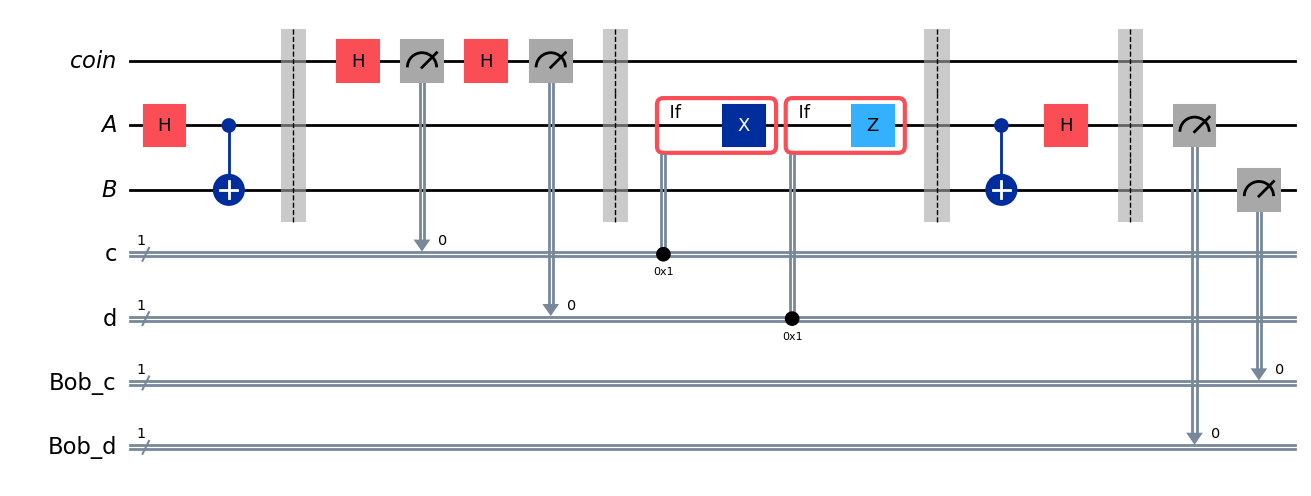

In [ ]:
random_bit_generator = QuantumRegister(1, 'coin')
qubit_Alice = QuantumRegister(1, 'A')
qubit_Bob = QuantumRegister(1, 'B')
Alice_c = ClassicalRegister(1, 'c')
Alice_d = ClassicalRegister(1, 'd')

test = QuantumCircuit(random_bit_generator, qubit_Alice, qubit_Bob, Alice_c, Alice_d)

# Again preparing the e-bit
test.h(qubit_Alice)
test.cx(qubit_Alice, qubit_Bob)
test.barrier()


# Using the coin qubit twice to generate Alice's bits 'c' and 'd'.
test.h(random_bit_generator)
test.measure(random_bit_generator, Alice_c)
test.h(random_bit_generator)
test.measure(random_bit_generator, Alice_d)
test.barrier()

# Now protocol runs, starting with Alice's actions, which depends on her bits
with test.if_test((Alice_c, 1), label = "X"):
  test.x(qubit_Alice)

with test.if_test((Alice_d, 1), label = "Z"):
  test.z(qubit_Alice)
test.barrier()

# Bob's Action
test.cx(qubit_Alice, qubit_Bob)
test.h(qubit_Alice)
test.barrier()

# Bob's Action: Creating ouput bits of Bob after measuremnt and then streamline it with my circuit
Bob_c = ClassicalRegister(1, "Bob_c")
Bob_d = ClassicalRegister(1, "Bob_d")

test.add_register(Bob_c)
test.add_register(Bob_d)
test.measure(qubit_Alice, Bob_d )
test.measure(qubit_Bob, Bob_c)

display(test.draw('mpl'))

Running the Aer simulator shows the results:

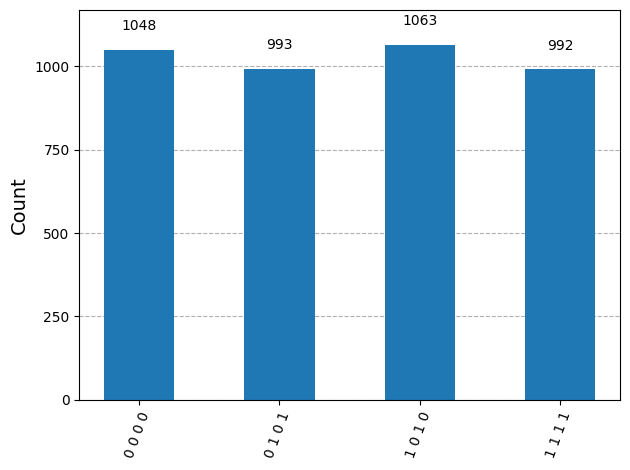

In [ ]:
result = AerSimulator().run(test, shots = 4096).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

**Result**

The random bit generator generates Alice's bits 'c' and 'd' randomly instead of fixing them. As a result, we get four 4-bit outcomes (0000, 0101, 1010, 1111) with approximately equal probabilities. The probabilities of our outcomes are given by:
1. P(0000) ≈ 1048/4096 ≈ 25.6%
2. P(0101) ≈ 993/4096 ≈ 24.2%
3. P(1010) ≈ 1063/4096 ≈ 26%
4. P(1111) ≈ 992/4096 ≈ 24.2%

Each 4-bit outcome is structured as Alice's bits and Bob's bits, i.e., cdcd. The fact that every observed outcome has this repeated-pair structure is the key result that Bob's decoded bits are bit-for-bit identical to Alice's original, randomly generated bits in every single shot.

**Why only 4-bit outcomes appear?**

With four classical bits, there are 16 possible outcomes. But only four of them are observed in our graph (the ones where the first two bits and the last two bits are equal) because:

* The other outcomes (e.g., 0001, 0110, 1100 etc.) would represent a decoding error. Since the simulation is noiseless and error-free, this never happens, and those outcomes have exactly zero counts.
* The circuit is a noise-free deterministic quantum simulation, and there is no mechanism in an ideal circuit for Bob's bits to differ from Alice's bits.
* The only randomness in the circuit comes from the coin qubit which determines what Alice sends (c, d) for every individual shot; Bob's output always matches.

### **6. Conclusion:**

Both simulations confirm 100% fidelity of the superdense coding protocol. Bob correctly recovers Alice's 2 classical bits from a single transmitted qubit in every shot, for both "fixed test case" and "randomized inputs". It validates the theoretical claim that shared entanglement doubles the classical information capacity of a single qubit.